 <center> <h1> <b> Pattern Recognition and Machine Learning (EE5610 - EE2802 - AI2000 - AI5000) </b> </h1> </center>

<b> Programming Assignment - 04 : Neural Networks </b>


This programming assignment gives you a chance to perform the classification task using neural networks. You will get to build a neural network from scratch and train and test it on a standard classification dataset. Further you will learn different tricks and techniques to train a neural network eficiently by observing few important issues and trying to overcome them. This includes observing the performance of the network for different activation functions and optimization algorithms. We will conclude with implementation of various regularization techniques to overcome the problems of overfitting and vanishing gradients.

<b> Instructions </b>
1. Plagiarism is strictly prohibited.
2. Delayed submissions will be penalized with a scaling factor of 0.5 per day.
3. Please DO NOT use any machine learning libraries unless and otherwise specified.








<b>  Part - (1) : Develop a neural network based classification network from scratch: </b>  This programming assignment uses MNIST digit dataset. It consists of large collection of handwritten digits from 0 to 9. These images are formated as 28x28 pixel gray scale images. The objective of this programming assignment is to design a neural network architecture that takes input as 28x28 image (or 784 dimensional vector) as input and predicts the digit information in it. Although there are diffrent varieties of neural network architecture to solve this task, this programming assignment uses only the feed forward network.  

<dt> <h6> 1. Load MNIST data and create train, test splits </dt> </h6>

<dd> <h6> - The MNIST dataset consists of around 70,000 images. Divide the dataset into two segments: training and testing. Allocate 60,000 images for training and 10,000 images for testing
</dd> </h6>
<dd> <h6> - Code for downloading the data and creating train-test splits is provided </dd> </h6>

<dt> <h6> 2. Design a simple classification network </dt> </h6>

<dd> <h6> - Let us use three layer feed-forward neral network. Use 512 nodes in the hidden layers and 10 nodes in the output layer. The output $\textbf{y}$ from the input $\textbf{x}$ is computed as follows </dd> </h6>
<dd> <h6> <center> $ \textbf{y} = h(\textbf{W}_{3}g(\textbf{W}_{2}g(\textbf{W}_{1}\textbf{x}))) $ </center> </dd> </h6>
<dd> <h6> where $\textbf{W}_{1} \in \mathcal{R}^{512 \times 768}$,$\textbf{W}_{2} \in \mathcal{R}^{512 \times 512}$,$\textbf{W}_{3} \in \mathcal{R}^{10 \times 512} $ are the parameters of the network. g(.) is the hidden layer activation function. h(.) is the output layer activation function   </dd> </h6>
<dd> <h6> - Consider g(.) as ReLU activation function. Softmax activation function should be used at the last layer h(.), to get the posterior probability of the classes. </dd> </h6>

<dt> <h6> - Training classification network: </dt> </h6>

<dd> <h6>  - Flatten the 28x28 images to arrive at 784 dimensional vector.  </dd> </h6>  
<dd> <h6> - Randomly initialize the parameters of network, $\textbf{W}_{1} \in \mathcal{R}^{768 \times 512}$,$\textbf{W}_{2} \in \mathcal{R}^{512 \times 512}$,$\textbf{W}_{3} \in \mathcal{R}^{512 \times 10}$  </dd> </h6>
<dd> <h6> - Feedforward the batch of input vectors to get the posterior probability of classes.  </dd> </h6>
<dd> <h6> - Compute the loss between the estimated posterior probabilities and the true targets. </dd> </h6>  
<dd> <h6> - Update the parameters of network to minimize the loss function.  </dd> </h6>
<dd> <h6> <dd> <h6> - Backpropagate the loss function to get the gradients.  </dd> </h6> </dd> </h6>  

<dd> <h6> <dd> <h6> - You can use stochastic gradient descent (SGD) optimization algorithm to update the parameters.  </dd> </h6> </dd> </h6>  
<dd> <h6> <dd> <h6> - Cleverly set the hyperparameters involved in this optimization process. </dd> </h6> </dd> </h6>

<dt> <h6> 3. Evaluate the performance of classification network </dd> </h6>
<dd> <h6> - feed-forward the MNIST data through the trained classification network to get class posteriors. </dd> </h6>  
<dd> <h6> - Assign the input to the class having maximum posterior probability </dd> </h6>  
<dd> <h6> - Compute the loss and accuaracy </dd> </h6>  
<dd> <h6> - Report your observations </dd> </h6>  





In [4]:
#All imports
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import collections

In [3]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test = x_test.reshape(x_test.shape[0], -1) / 255.0
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print("Flattened Testing data", x_test)
print("Testing labels", y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Flattened Testing data [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Testing labels [[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [5]:
##################################################
#Load MNIST data.
##################################################
import torchvision.datasets as datasets
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

#Training data
mnist_traindata = mnist_trainset.data.numpy()
mnist_trainlabel = mnist_trainset.targets.numpy()
print("Training data",mnist_traindata.shape)
print("Training labels",mnist_trainlabel.shape)

#Testing data
mnist_testdata = mnist_testset.data.numpy()
mnist_testlabel = mnist_testset.targets.numpy()
print("Testing data",mnist_testdata.shape)
print("Testing labels",mnist_testlabel.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 36.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 931kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.26MB/s]

Training data (60000, 28, 28)
Training labels (60000,)
Testing data (10000, 28, 28)
Testing labels (10000,)


In [6]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

print(mnist_traindata.shape,mnist_trainlabel.shape)
print(mnist_testdata.shape,mnist_testlabel.shape)

#print(mnist_traindata[0]/255.0)
#print(x_train[0])

a=mnist_traindata[0]/255.0
a=a.reshape(-1,28*28)
b=x_train[0]
print(a.shape)
print(b.shape)
print(a==b)


(60000, 784) (60000, 10)
(10000, 784) (10000, 10)
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
(1, 784)
(784,)
[[ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  T

In [ ]:
##################################################
#Load MNIST data.
##################################################
import torchvision.datasets as datasets
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

#Training data
mnist_traindata = mnist_trainset.data.numpy()
mnist_trainlabel = mnist_trainset.targets.numpy()
print("Training data",mnist_traindata.shape)
print("Training labels",mnist_trainlabel.shape)

#Testing data
mnist_testdata = mnist_testset.data.numpy()
mnist_testlabel = mnist_testset.targets.numpy()
print("Testing data",mnist_testdata.shape)
print("Testing labels",mnist_testlabel.shape)


mnist_traindata = mnist_traindata.reshape(mnist_traindata.shape[0],-1)/255.0
mnist_testdata = mnist_testdata.reshape(mnist_testdata.shape[0],-1)/255.0
mnist_trainlabel = to_categorical(mnist_trainlabel, num_classes=10)
mnist_testlabel = to_categorical(mnist_testlabel, num_classes=10)

##################################################
#Define the architecture
##################################################

#Complete the below function to impliment ReLU activation function
def ReLu(inp):

  outp=np.maximum(0,inp)

  return outp

#Complete the below function to impliment gradient of ReLU activation function
def gradReLu(inp):
  outp=(inp>=0).astype(float)

  return outp

#Complete the below function to impliment softmax activation function
def softmax(inp):
  exp_inp=np.exp(inp-np.max(inp,axis=1,keepdims=True))    #subtracting max to stop overflow for exponential function
  sum_exp_inp=np.sum(exp_inp,axis=1,keepdims=True)    #sum across rows
  outp=exp_inp/sum_exp_inp

  return outp

#Complete the below function to impliment forward propagation of data
def fwdPropagate(inputs, weights):
  #Inputs: input data, paramters of network
  W1, W2, W3 = weights
  z1 = inputs@W1
  a1 = ReLu(z1)
  z2 = a1@W2
  a2 = ReLu(z2)
  z3 = a2@W3
  y_hat = softmax(z3)

  #Return the requires outputs, i.e., final output and intermediate activations
  outps = [y_hat,z3,a2,z2,a1,z1]
  return outps

#Complete the below function to compute the gradients
def computeGradients(inputs, targets, weights, activations):
  #Inputs: input data, targets, parameters of netwrok, intermediate activations
  W1, W2, W3 = weights
  y_hat,z3,a2,z2,a1,z1 = activations

  #Compute the loss
  loss = -np.sum(targets*np.log(y_hat+(1e-10)))

  #Compote the derivative of loss at parameters
  dj_dz3 = y_hat-targets      #derivative of loss function w.r.t z3
  dj_dw3 = a2.T@dj_dz3/(inputs.shape[0]+(1e-10))
  dj_da2 = dj_dz3@W3.T
  dj_dz2 = dj_da2*gradReLu(z2)
  dj_dw2 = a1.T@dj_dz2/(inputs.shape[0]+(1e-10))
  dj_da1 = dj_dz2@W2.T
  dj_dz1 = dj_da1*gradReLu(z1)
  dj_dw1 = inputs.T@dj_dz1/(inputs.shape[0]+(1e-10))

  #Return the gradients
  return [dj_dw1, dj_dw2, dj_dw3]

#Complete the below function to update the parameters using the above computed gradients
def applyGradients(weights, gradients, learning_rate):
  #Inputs: weights, gradients, and learning rate
  W1, W2, W3 = weights
  dj_dw1, dj_dw2, dj_dw3 = gradients

  W1 = W1-learning_rate*dj_dw1
  W2 = W2-learning_rate*dj_dw2
  W3 = W3-learning_rate*dj_dw3

  #Return the updated parameters
  return [W1, W2, W3]

#Complete the below function to complete the backpropagation ste
def backPropagate(inputs, targets, weights, activations, learning_rate):
  #Inputs: input data, targets, parameters of network, intermediate activations, learning rate of optimization algorithm

  #Compute the gradients
  gradients = computeGradients(inputs, targets, weights, activations)

  #Update the paramters using gradients
  weights = applyGradients(weights, gradients, learning_rate)

  #Return the updated parameters
  return weights


##################################################
#Train the network
##################################################

#Complete the below function to complete the training of network
def training(inputs, targets_idx, batch_size = 128, epochs=30, train_val_split=0.8, learning_rate=0.001):

  #Set the hyperparameters
  hidden_units = 512
  n_classes = 10
  n_samples = inputs.shape[0]
  n_batches = int(n_samples/batch_size)

  #Split the training data into two parts.
  #Use 90 percent of training data for training the network.
  #Remaining 10 percent as validation data
  split_point = int(train_val_split*n_samples)
  train_inputs = inputs[:split_point]
  val_inputs = inputs[split_point:]
  train_targets = targets_idx[:split_point]
  val_targets = targets_idx[split_point:]

  #Randomly initialize the weights
  W1 = np.random.randn(784, hidden_units) * np.sqrt(2.0 / 784)      #He initialization (random init scaled for ReLU)
  W2 = np.random.randn(hidden_units, hidden_units) * np.sqrt(2.0 / hidden_units)
  W3 = np.random.randn(hidden_units, n_classes) * np.sqrt(2.0 / hidden_units)
  weights = [W1, W2, W3]

  #Interate for epochs times
  for epoch in range(epochs):
    #Shuffle the training data
    indices = np.arange(train_inputs.shape[0])
    np.random.shuffle(indices)
    train_inputs = train_inputs[indices]
    train_targets = train_targets[indices]

    #Interate through the batches of data
    for batch in range(n_batches):
      #Get the batch of data
      start_index = batch*batch_size
      end_index = start_index+batch_size
      batch_inputs = train_inputs[start_index:end_index]
      batch_targets = train_targets[start_index:end_index]

      #Forward propagation
      activations = fwdPropagate(batch_inputs, weights)

      #Backward propagation
      weights = backPropagate(batch_inputs, batch_targets, weights, activations, learning_rate)

    #Compute outpus on trianing data
    train_activations = fwdPropagate(train_inputs, weights)
    train_outputs = train_activations[0]

    #Compute training accuracy, and training error
    train_predictions = np.argmax(train_outputs, axis=1)
    train_targets_1d = np.argmax(train_targets, axis=1)         #getting values to a 1D array
    train_accuracy = np.mean(train_predictions == train_targets_1d)
    train_error = 1 - train_accuracy

    #Compute outputs on validation data
    val_activations = fwdPropagate(val_inputs, weights)
    val_outputs = val_activations[0]

    #Compute validation accuracy, and validation error
    val_predictions = np.argmax(val_outputs, axis=1)
    val_targets_1d = np.argmax(val_targets, axis=1)
    val_accuracy = np.mean(val_predictions == val_targets_1d)
    val_error = 1 - val_accuracy

    #Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
    print(f"Epoch: {epoch+1}, Training Error: {train_error:.3f}, Training Accuracy: {train_accuracy:.3f}, Validation Error: {val_error:.3f}, Validation Accuracy: {val_accuracy:.3f}")

    #Save the parameters of network
    final_weights = weights

  return final_weights


#Call the training function to train the network
final_weights = training(mnist_traindata, mnist_trainlabel, batch_size = 128, epochs = 10, train_val_split = 0.8, learning_rate = 0.001)

##################################################
#Evaluate the performance on test data
##################################################
def test_perf(inputs, targets, weights):
  #Forward propagation
  activations = fwdPropagate(inputs, weights)
  outputs = activations[0]

  #Compute accuracy, and error
  predictions = np.argmax(outputs, axis=1)
  targets_1d = np.argmax(targets, axis=1)
  accuracy = np.mean(predictions == targets_1d)
  error = 1 - accuracy
  return accuracy,error

test_accuracy, test_error = test_perf(mnist_testdata, mnist_testlabel, final_weights)
print(f"Test Accuracy: {test_accuracy:.3f}")


<b> Report your observations </b>

1.We can see that there is no significant gap between training accuracy and validation accuracy in every epoch which implies that model is not overfitting.

2.Accuracy has a improvement when the parameters like learning rate increasing slightly will improve the rate of convergence,also on increasing epochs there will be significant improvement as the model learns features of data more effectively.

3.These accuracies can be increased using better optimization methods than SGD which can be seen in following parts.



<b> Part - (2) : Understanding activation functions: </b> In this part you will learn to use different activation functions for the classification task and compare their performances.

<dt> <h6> 1. Train MNIST digit classification network with different activation functions i.e. Sigmoid, Tanh, ReLU, LeakyReLU etc. You can stick to stochastic gradient descent optimization algorithm for this part </dt> </h6>
<dt> <h6> 2. Report the accuray on MNIST test data for all the experiments. Write down your observations in the report.</br> </dt> </h6>



In [ ]:
##################################################
#Load MNIST data.
##################################################
import torchvision.datasets as datasets
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

#Training data
mnist_traindata = mnist_trainset.data.numpy()
mnist_trainlabel = mnist_trainset.targets.numpy()
print("Training data",mnist_traindata.shape)
print("Training labels",mnist_trainlabel.shape)

#Testing data
mnist_testdata = mnist_testset.data.numpy()
mnist_testlabel = mnist_testset.targets.numpy()
print("Testing data",mnist_testdata.shape)
print("Testing labels",mnist_testlabel.shape)


mnist_traindata = mnist_traindata.reshape(mnist_traindata.shape[0],-1)/255.0
mnist_testdata = mnist_testdata.reshape(mnist_testdata.shape[0],-1)/255.0
mnist_trainlabel = to_categorical(mnist_trainlabel, num_classes=10)
mnist_testlabel = to_categorical(mnist_testlabel, num_classes=10)

#activation functions
def sigmoid(inp):
    return 1 / (1 + np.exp(-inp))

def grad_sigmoid(inp):
    s = sigmoid(inp)
    return s * (1 - s)

def tanh(inp):
    return np.tanh(inp)

def grad_tanh(inp):
    return 1 - np.tanh(inp)**2

def leakyrelu(inp, alpha=0.01):                     #PReLu if alpha != 0.01
    return np.where(inp > 0, inp, alpha * inp)

def grad_leakyrelu(inp, alpha=0.01):
    return np.where(inp > 0, 1, alpha)

#softmax function
def softmax(inp):
  exp_inp=np.exp(inp-np.max(inp,axis=1,keepdims=True))    #subtracting max to stop overflow for exponential function
  sum_exp_inp=np.sum(exp_inp,axis=1,keepdims=True)    #sum across rows
  outp=exp_inp/sum_exp_inp

  return outp

#forward propagation function for any activation function
def fwdPropagate(inputs, weights, activation):
    W1, W2, W3 = weights
    z1 = inputs@W1
    a1 = activation(z1)
    z2 = a1@W2
    a2 = activation(z2)
    z3 = a2@W3
    y_hat = softmax(z3)
    return [y_hat, z3, a2, z2, a1, z1]

#computing gradients for any type of activation functions
def computeGradients(inputs, targets, weights, activations, grad_activation):
  #Inputs: input data, targets, parameters of netwrok, intermediate activations
  W1, W2, W3 = weights
  y_hat,z3,a2,z2,a1,z1 = activations

  #Compute the loss
  loss = -np.sum(targets*np.log(y_hat+(1e-10)))

  #Compote the derivative of loss at parameters
  dj_dz3 = y_hat-targets      #derivative of loss function w.r.t z3
  dj_dw3 = a2.T@dj_dz3/(inputs.shape[0]+(1e-10))
  dj_da2 = dj_dz3@W3.T
  dj_dz2 = dj_da2*grad_activation(z2)
  dj_dw2 = a1.T@dj_dz2/(inputs.shape[0]+(1e-10))
  dj_da1 = dj_dz2@W2.T
  dj_dz1 = dj_da1*grad_activation(z1)
  dj_dw1 = inputs.T@dj_dz1/(inputs.shape[0]+(1e-10))

  #Return the gradients
  return [dj_dw1, dj_dw2, dj_dw3]

def applyGradients(weights, gradients, learning_rate):
  #Inputs: weights, gradients, and learning rate
  W1, W2, W3 = weights
  dj_dw1, dj_dw2, dj_dw3 = gradients

  W1 = W1-learning_rate*dj_dw1
  W2 = W2-learning_rate*dj_dw2
  W3 = W3-learning_rate*dj_dw3

  #Return the updated parameters
  return [W1, W2, W3]


#backpropagation function
def backPropagate(inputs, targets, weights, activations, learning_rate, grad_activation):
  #Inputs: input data, targets, parameters of network, intermediate activations, learning rate of optimization algorithm

  #Compute the gradients
  gradients = computeGradients(inputs, targets, weights, activations, grad_activation)

  #Update the paramters using gradients
  weights = applyGradients(weights, gradients, learning_rate)

  #Return the updated parameters
  return weights

##################################################
#Train the network with different activation functions
##################################################
def training(inputs, targets_idx, activation, grad_activation, activation_name, batch_size = 128, epochs=30, train_val_split=0.8, learning_rate=0.001):

  #Set the hyperparameters
  hidden_units = 512
  n_classes = 10
  n_samples = inputs.shape[0]
  n_batches = int(n_samples/batch_size)

  #Split the training data into two parts.
  #Use 90 percent of training data for training the network.
  #Remaining 10 percent as validation data
  split_point = int(train_val_split*n_samples)
  train_inputs = inputs[:split_point]
  val_inputs = inputs[split_point:]
  train_targets = targets_idx[:split_point]
  val_targets = targets_idx[split_point:]

  #Randomly initialize the weights
  W1 = np.random.randn(784, hidden_units) * np.sqrt(2.0 / 784)      #He initialization (random init scaled for ReLU)
  W2 = np.random.randn(hidden_units, hidden_units) * np.sqrt(2.0 / hidden_units)
  W3 = np.random.randn(hidden_units, n_classes) * np.sqrt(2.0 / hidden_units)
  weights = [W1, W2, W3]

  #Interate for epochs times
  for epoch in range(epochs):
    #Shuffle the training data
    indices = np.arange(train_inputs.shape[0])
    np.random.shuffle(indices)
    train_inputs = train_inputs[indices]
    train_targets = train_targets[indices]

    #Interate through the batches of data
    for batch in range(n_batches):
      #Get the batch of data
      start_index = batch*batch_size
      end_index = start_index+batch_size
      batch_inputs = train_inputs[start_index:end_index]
      batch_targets = train_targets[start_index:end_index]

      #Forward propagation
      activations = fwdPropagate(batch_inputs, weights, activation)

      #Backward propagation
      weights = backPropagate(batch_inputs, batch_targets, weights, activations, learning_rate, grad_activation)

    #Compute outpus on trianing data
    train_activations = fwdPropagate(train_inputs, weights, activation)
    train_outputs = train_activations[0]

    #Compute training accuracy, and training error
    train_predictions = np.argmax(train_outputs, axis=1)
    train_targets_1d = np.argmax(train_targets, axis=1)         #getting values to a 1D array
    train_accuracy = np.mean(train_predictions == train_targets_1d)
    train_error = 1 - train_accuracy

    #Compute outputs on validation data
    val_activations = fwdPropagate(val_inputs, weights, activation)
    val_outputs = val_activations[0]

    #Compute validation accuracy, and validation error
    val_predictions = np.argmax(val_outputs, axis=1)
    val_targets_1d = np.argmax(val_targets, axis=1)
    val_accuracy = np.mean(val_predictions == val_targets_1d)
    val_error = 1 - val_accuracy

    #Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
    print(f"Activation function: {activation_name}, Epoch: {epoch+1}, Training Error: {train_error:.3f}, Training Accuracy: {train_accuracy:.3f}, Validation Error: {val_error:.3f}, Validation Accuracy: {val_accuracy:.3f}")

    #Save the parameters of network
    final_weights = weights

  return final_weights

#Call the training function to train the network
final_weights_sigmoid = training(mnist_traindata, mnist_trainlabel, sigmoid, grad_sigmoid, "sigmoid", batch_size = 128, epochs = 10, train_val_split = 0.8, learning_rate = 0.001)
final_weights_tanh = training(mnist_traindata, mnist_trainlabel, tanh, grad_tanh, "tanh", batch_size = 128, epochs = 30, train_val_split = 0.8, learning_rate = 0.001)
final_weights_leakyrelu = training(mnist_traindata, mnist_trainlabel, leakyrelu, grad_leakyrelu, "leakyrelu", batch_size = 128, epochs = 10, train_val_split = 0.8, learning_rate = 0.001)


##################################################
#Evaluate the performance on MNIST test data
##################################################
def test_perf(inputs, targets, weights, activation):
  #Forward propagation
  activations = fwdPropagate(inputs, weights, activation)
  outputs = activations[0]

  #Compute accuracy, and error
  predictions = np.argmax(outputs, axis=1)
  targets_1d = np.argmax(targets, axis=1)
  accuracy = np.mean(predictions == targets_1d)
  error = 1 - accuracy
  return accuracy,error

#performance of sigmoid activation on test data
sigmoid_test_accuracy, test_error = test_perf(mnist_testdata, mnist_testlabel, final_weights_sigmoid, sigmoid)
print(f"Test Accuracy for Sigmoid: {sigmoid_test_accuracy:.3f}")

#performance of tanh activation on test data
tanh_test_accuracy, test_error = test_perf(mnist_testdata, mnist_testlabel, final_weights_tanh, tanh)
print(f"Test Accuracy for Tanh: {tanh_test_accuracy:.3f}")

#performance of leakyrelu activation on test data
leakyrelu_test_accuracy, test_error = test_perf(mnist_testdata, mnist_testlabel, final_weights_leakyrelu, leakyrelu)
print(f"Test Accuracy for LeakyReLU: {leakyrelu_test_accuracy:.3f}")




<b> Report your observations </b>

1.We can see that relu,leaky relu activations are giving better results than tanh (or) sigmoid which is mainky because they overcome vanishing gradient problem which can be seen from their functions.This promotes faster convergence.

2.There is very big improvement in accuracy on using tanh as activation with more number of epochs but also the gap b/w training accuracy and validation accuracy are increasing as the epochs increase.From this,we can say that model is getting overfitted to the data on increasing number of epochs.

3.After checking outputs I'm getting highest accuracy for leaky relu which means it is more effective.



<b> Part - (3) : Understanding optimization algorithms: </b> In this part you will learn to use different optimiztion algorithm apart from SGD.

<dt> <h6> 1. Using the best activation function from Part - (2), train the classification network using Adam optimization algorithm. </dt> </h6>
<dt> <h6> 3. Compare the accuracy of the networks trained with SGD and Adam optimization algorithms. </dt> </h6>
<dt> <h6> 4. Report your observations. </dt> </h6>

In [ ]:
#best activation function is leakyrelu
def leakyrelu(inp, alpha=0.01):                     #PReLu if alpha != 0.01
    return np.where(inp > 0, inp, alpha * inp)

def grad_leakyrelu(inp, alpha=0.01):
    return np.where(inp > 0, 1, alpha)

#softmax function
def softmax(inp):
  exp_inp=np.exp(inp-np.max(inp,axis=1,keepdims=True))    #subtracting max to stop overflow for exponential function
  sum_exp_inp=np.sum(exp_inp,axis=1,keepdims=True)    #sum across rows
  outp=exp_inp/sum_exp_inp

  return outp

#forward propagation function for any activation function
def fwdPropagate(inputs, weights, activation):
    W1, W2, W3 = weights
    z1 = inputs@W1
    a1 = activation(z1)
    z2 = a1@W2
    a2 = activation(z2)
    z3 = a2@W3
    y_hat = softmax(z3)
    return [y_hat, z3, a2, z2, a1, z1]

#computing gradients for any type of activation functions
def computeGradients(inputs, targets, weights, activations, grad_activation):
  #Inputs: input data, targets, parameters of netwrok, intermediate activations
  W1, W2, W3 = weights
  y_hat,z3,a2,z2,a1,z1 = activations

  #Compute the loss
  loss = -np.sum(targets*np.log(y_hat+(1e-10)))

  #Compote the derivative of loss at parameters
  dj_dz3 = y_hat-targets      #derivative of loss function w.r.t z3
  dj_dw3 = a2.T@dj_dz3/(inputs.shape[0]+(1e-10))
  dj_da2 = dj_dz3@W3.T
  dj_dz2 = dj_da2*grad_activation(z2)
  dj_dw2 = a1.T@dj_dz2/(inputs.shape[0]+(1e-10))
  dj_da1 = dj_dz2@W2.T
  dj_dz1 = dj_da1*grad_activation(z1)
  dj_dw1 = inputs.T@dj_dz1/(inputs.shape[0]+(1e-10))

  #Return the gradients
  return [dj_dw1, dj_dw2, dj_dw3]

def applyGradients(weights, gradients, learning_rate):
  #Inputs: weights, gradients, and learning rate
  W1, W2, W3 = weights
  dj_dw1, dj_dw2, dj_dw3 = gradients

  W1 = W1-learning_rate*dj_dw1
  W2 = W2-learning_rate*dj_dw2
  W3 = W3-learning_rate*dj_dw3

  #Return the updated parameters
  return [W1, W2, W3]


#backpropagation function
def backPropagate(inputs, targets, weights, activations, learning_rate, grad_activation):
  #Inputs: input data, targets, parameters of network, intermediate activations, learning rate of optimization algorithm

  #Compute the gradients
  gradients = computeGradients(inputs, targets, weights, activations, grad_activation)

  #Update the paramters using gradients
  weights = applyGradients(weights, gradients, learning_rate)

  #Return the updated parameters
  return weights

def SGD_optimizer(inputs, targets_idx, activation, grad_activation, optimizer_name, batch_size = 128, epochs=30, train_val_split=0.8, learning_rate=0.001):

  #Set the hyperparameters
  hidden_units = 512
  n_classes = 10
  n_samples = inputs.shape[0]
  n_batches = int(n_samples/batch_size)

  #Split the training data into two parts.
  #Use 90 percent of training data for training the network.
  #Remaining 10 percent as validation data
  split_point = int(train_val_split*n_samples)
  train_inputs = inputs[:split_point]
  val_inputs = inputs[split_point:]
  train_targets = targets_idx[:split_point]
  val_targets = targets_idx[split_point:]

  #Randomly initialize the weights
  W1 = np.random.randn(784, hidden_units) * np.sqrt(2.0 / 784)      #He initialization (random init scaled for ReLU)
  W2 = np.random.randn(hidden_units, hidden_units) * np.sqrt(2.0 / hidden_units)
  W3 = np.random.randn(hidden_units, n_classes) * np.sqrt(2.0 / hidden_units)
  weights = [W1, W2, W3]

  #Interate for epochs times
  for epoch in range(epochs):
    #Shuffle the training data
    indices = np.arange(train_inputs.shape[0])
    np.random.shuffle(indices)
    train_inputs = train_inputs[indices]
    train_targets = train_targets[indices]

    #Interate through the batches of data
    for batch in range(n_batches):
      #Get the batch of data
      start_index = batch*batch_size
      end_index = start_index+batch_size
      batch_inputs = train_inputs[start_index:end_index]
      batch_targets = train_targets[start_index:end_index]

      #Forward propagation
      activations = fwdPropagate(batch_inputs, weights, activation)

      #Backward propagation
      weights = backPropagate(batch_inputs, batch_targets, weights, activations, learning_rate, grad_activation)

    #Compute outpus on trianing data
    train_activations = fwdPropagate(train_inputs, weights, activation)
    train_outputs = train_activations[0]

    #Compute training accuracy, and training error
    train_predictions = np.argmax(train_outputs, axis=1)
    train_targets_1d = np.argmax(train_targets, axis=1)         #getting values to a 1D array
    train_accuracy = np.mean(train_predictions == train_targets_1d)
    train_error = 1 - train_accuracy

    #Compute outputs on validation data
    val_activations = fwdPropagate(val_inputs, weights, activation)
    val_outputs = val_activations[0]

    #Compute validation accuracy, and validation error
    val_predictions = np.argmax(val_outputs, axis=1)
    val_targets_1d = np.argmax(val_targets, axis=1)
    val_accuracy = np.mean(val_predictions == val_targets_1d)
    val_error = 1 - val_accuracy

    #Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
    print(f"Optimizer Name: {optimizer_name}, Epoch: {epoch+1}, Training Error: {train_error:.3f}, Training Accuracy: {train_accuracy:.3f}, Validation Error: {val_error:.3f}, Validation Accuracy: {val_accuracy:.3f}")

    #Save the parameters of network
    final_weights = weights

  return final_weights

final_weights_sgd = SGD_optimizer(mnist_traindata, mnist_trainlabel, leakyrelu, grad_leakyrelu, "SGD", batch_size = 128, epochs = 10, train_val_split = 0.8, learning_rate = 0.001)

##################################################
#Train the network using Adam optimizer
##################################################
def adam_optimization(inputs, targets_idx, activation, grad_activation, optimizer_name, batch_size=128, epochs=30, train_val_split=0.8, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-10):

 #Set the hyperparameters
  hidden_units = 512
  n_classes = 10
  n_samples = inputs.shape[0]
  n_batches = int(n_samples/batch_size)

  #Split the training data into two parts.
  #Use 90 percent of training data for training the network.
  #Remaining 10 percent as validation data
  split_point = int(train_val_split*n_samples)
  train_inputs = inputs[:split_point]
  val_inputs = inputs[split_point:]
  train_targets = targets_idx[:split_point]
  val_targets = targets_idx[split_point:]

  #Randomly initialize the weights
  W1 = np.random.randn(784, hidden_units) * np.sqrt(2.0 / 784)      #He initialization (random init scaled for ReLU)
  W2 = np.random.randn(hidden_units, hidden_units) * np.sqrt(2.0 / hidden_units)
  W3 = np.random.randn(hidden_units, n_classes) * np.sqrt(2.0 / hidden_units)
  weights = [W1, W2, W3]

 #moments of adam optimization
  m1 = [np.zeros_like(w) for w in weights]
  m2 = [np.zeros_like(w) for w in weights]
  t = 0  # Timestep

  for epoch in range(epochs):
        indices = np.arange(train_inputs.shape[0])
        np.random.shuffle(indices)
        train_inputs = train_inputs[indices]
        train_targets = train_targets[indices]

        for batch in range(n_batches):
            start_index = batch * batch_size
            end_index = start_index + batch_size
            batch_inputs = train_inputs[start_index:end_index]
            batch_targets = train_targets[start_index:end_index]

            activations = fwdPropagate(batch_inputs, weights, activation)
            gradients = computeGradients(batch_inputs, batch_targets, weights, activations, grad_activation)

            t = t+1
            for i in range(len(weights)):
                m1[i] = beta1 * m1[i] + (1 - beta1) * gradients[i]
                m2[i] = beta2 * m2[i] + (1 - beta2) * gradients[i]**2
                m1_hat = m1[i] / ((1 - beta1**t) + epsilon)
                m2_hat = m2[i] / ((1 - beta2**t) + epsilon)
                weights[i] = weights[i] - learning_rate * m1_hat / (np.sqrt(m2_hat) + epsilon)

        #Compute outpus on trianing data
        train_activations = fwdPropagate(train_inputs, weights, activation)
        train_outputs = train_activations[0]

        #Compute training accuracy, and training error
        train_predictions = np.argmax(train_outputs, axis=1)
        train_targets_1d = np.argmax(train_targets, axis=1)         #getting values to a 1D array
        train_accuracy = np.mean(train_predictions == train_targets_1d)
        train_error = 1 - train_accuracy

        #Compute outputs on validation data
        val_activations = fwdPropagate(val_inputs, weights, activation)
        val_outputs = val_activations[0]

        #Compute validation accuracy, and validation error
        val_predictions = np.argmax(val_outputs, axis=1)
        val_targets_1d = np.argmax(val_targets, axis=1)
        val_accuracy = np.mean(val_predictions == val_targets_1d)
        val_error = 1 - val_accuracy

        #Print the statistics of training, i.e., training error, training accuracy, validation error, and validation accuracy
        print(f"Optimizer Name: {optimizer_name}, Epoch: {epoch+1}, Training Error: {train_error:.3f}, Training Accuracy: {train_accuracy:.3f}, Validation Error: {val_error:.3f}, Validation Accuracy: {val_accuracy:.3f}")

        #Save the parameters of network
        final_weights = weights

  return final_weights

final_weights_adam = adam_optimization(mnist_traindata, mnist_trainlabel, leakyrelu, grad_leakyrelu, "Adam", batch_size = 128, epochs = 10, train_val_split = 0.8, learning_rate = 0.001, beta1=0.9, beta2=0.999, epsilon=1e-10)

def test_perf(inputs, targets, weights, activation):
  #Forward propagation
  activations = fwdPropagate(inputs, weights, activation)
  outputs = activations[0]

  #Compute accuracy, and error
  predictions = np.argmax(outputs, axis=1)
  targets_1d = np.argmax(targets, axis=1)
  accuracy = np.mean(predictions == targets_1d)
  error = 1 - accuracy
  return accuracy,error

sgd_test_accuracy, test_error = test_perf(mnist_testdata, mnist_testlabel, final_weights_sgd, leakyrelu)
print(f"Test Accuracy for SGD: {sgd_test_accuracy:.3f}")

adam_test_accuracy, test_error = test_perf(mnist_testdata, mnist_testlabel, final_weights_adam, leakyrelu)
print(f"Test Accuracy for Adam: {adam_test_accuracy:.3f}")

##################################################
#Compare the accuracies and report your observations
##################################################
print("\nComparison:")
if adam_test_accuracy > sgd_test_accuracy:
    print("Adam optimizer performed better than SGD optimizer")
elif sgd_test_accuracy > adam_test_accuracy:
    print(f"SGD optimizer performed better than Adam optimizer")
else:
    print("Both optimizers achieved the same accuracy.")



<b> Report your observations </b>

1.Adam optimizer is usually a better choice than SGD for training neural networks especially with complex models.It boosts convergence rate and finds a good solution efficiently.

2.Adam generalizes  better for unseen data with a smaller gap b/w validation and training accuracies.This suggests that the model is less prone to overfitting.

3.SGD can sometimes catch upto adam in later epochs but it is not very much consistent may be due to getting stuck at local minima.



<b> Part - (4) : Understanding regularization methods: </b> In this part of the assignment, you will learn about a few regularization techniques to reduce the overfitting problem. Using the above built network, include the following techniques to reduce the overfitting by retraining the network efficiently. Write down the accuracies for each case.
<dt> <h6> 1. Weight regularization: Add regularization term to the classification los </dt> </h6>
<dt> <h6> 2. Dropout with a probability of 0.2: Randomly drop the activation potentials of hidden neural with 0.2 probability. Disable the dropout layer in inference model. You can experiment with different dropout probabilities and report your observations.  </dt> </h6>
<dt> <h6> 3. Early stopping: Stop the network training when it is started to overfitting to training data. </dt> </h6>


In [ ]:
##################################################
#Load MNIST data.
##################################################
import torchvision.datasets as datasets
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

#Training data
mnist_traindata = mnist_trainset.data.numpy()
mnist_trainlabel = mnist_trainset.targets.numpy()
print("Training data",mnist_traindata.shape)
print("Training labels",mnist_trainlabel.shape)

#Testing data
mnist_testdata = mnist_testset.data.numpy()
mnist_testlabel = mnist_testset.targets.numpy()
print("Testing data",mnist_testdata.shape)
print("Testing labels",mnist_testlabel.shape)

mnist_traindata = mnist_traindata.reshape(mnist_traindata.shape[0],-1)/255.0
mnist_testdata = mnist_testdata.reshape(mnist_testdata.shape[0],-1)/255.0
mnist_trainlabel = to_categorical(mnist_trainlabel, num_classes=10)
mnist_testlabel = to_categorical(mnist_testlabel, num_classes=10)

def sigmoid(inp):
    return 1 / (1 + np.exp(-inp))

def grad_sigmoid(inp):
    s = sigmoid(inp)
    return s * (1 - s)

def tanh(inp):
    return np.tanh(inp)

def grad_tanh(inp):
    return 1 - np.tanh(inp)**2

def relu(inp):
    return np.maximum(0, inp)

def grad_relu(inp):
    return (inp >= 0).astype(float)

def leakyrelu(inp, alpha=0.01):
    return np.where(inp > 0, inp, alpha * inp)

def grad_leakyrelu(inp, alpha=0.01):
    return np.where(inp > 0, 1, alpha)

def softmax(inp):
    exp_inp = np.exp(inp - np.max(inp, axis=1, keepdims=True))
    sum_exp_inp = np.sum(exp_inp, axis=1, keepdims=True)
    return exp_inp / sum_exp_inp

def fwdPropagate(inputs, weights, activation, dropout_prob=0, dropout_masks=None):
    W1, W2, W3 = weights
    z1 = inputs @ W1
    a1 = activation(z1)
    if dropout_prob > 0 and dropout_masks is not None: a1 *= dropout_masks[0]
    z2 = a1 @ W2
    a2 = activation(z2)
    if dropout_prob > 0 and dropout_masks is not None: a2 *= dropout_masks[1]
    z3 = a2 @ W3
    y_hat = softmax(z3)
    return [y_hat, z3, a2, z2, a1, z1]

def computeGradients(inputs, targets, weights, activations, grad_activation, reg_lambda=0):
    W1, W2, W3 = weights
    y_hat, z3, a2, z2, a1, z1 = activations

    loss = -np.sum(targets * np.log(y_hat + (1e-10)))

    if reg_lambda > 0: loss += reg_lambda * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2))
    dj_dz3 = y_hat - targets
    dj_dw3 = a2.T @ dj_dz3 / (inputs.shape[0] + (1e-10))
    dj_da2 = dj_dz3 @ W3.T
    dj_dz2 = dj_da2 * grad_activation(z2)
    dj_dw2 = a1.T @ dj_dz2 / (inputs.shape[0] + (1e-10))
    dj_da1 = dj_dz2 @ W2.T
    dj_dz1 = dj_da1 * grad_activation(z1)
    dj_dw1 = inputs.T @ dj_dz1 / (inputs.shape[0] + (1e-10))
    if reg_lambda > 0:
        dj_dw1 += 2 * reg_lambda * W1
        dj_dw2 += 2 * reg_lambda * W2
        dj_dw3 += 2 * reg_lambda * W3
    return [dj_dw1, dj_dw2, dj_dw3], loss

##################################################
#Training with weight regularization
##################################################
def with_weight_regularization(inputs, targets_idx, activation, grad_activation, batch_size=128, epochs=30, train_val_split=0.8, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-10, reg_lambda=0.01):

    hidden_units = 512
    n_classes = 10
    n_samples = inputs.shape[0]
    n_batches = int(n_samples / batch_size)

    split_point = int(train_val_split * n_samples)
    train_inputs = inputs[:split_point]
    val_inputs = inputs[split_point:]
    train_targets = targets_idx[:split_point]
    val_targets = targets_idx[split_point:]

    W1 = np.random.randn(784, hidden_units) * np.sqrt(2.0 / 784)      #He initialization (random init scaled for ReLU)
    W2 = np.random.randn(hidden_units, hidden_units) * np.sqrt(2.0 / hidden_units)
    W3 = np.random.randn(hidden_units, n_classes) * np.sqrt(2.0 / hidden_units)
    weights = [W1, W2, W3]

    m1 = [np.zeros_like(w) for w in weights]
    m2 = [np.zeros_like(w) for w in weights]
    t = 0
    for epoch in range(epochs):
        indices = np.arange(train_inputs.shape[0])
        np.random.shuffle(indices)
        train_inputs = train_inputs[indices]
        train_targets = train_targets[indices]
        for batch in range(n_batches):
            start_index = batch * batch_size
            end_index = start_index + batch_size
            batch_inputs = train_inputs[start_index:end_index]
            batch_targets = train_targets[start_index:end_index]

            activations = fwdPropagate(batch_inputs, weights, activation)
            gradients, loss = computeGradients(batch_inputs, batch_targets, weights, activations, grad_activation, reg_lambda)
            t += 1
            for i in range(len(weights)):
                m1[i] = beta1 * m1[i] + (1 - beta1) * gradients[i]
                m2[i] = beta2 * m2[i] + (1 - beta2) * gradients[i]**2
                m1_hat = m1[i] / ((1 - beta1**t) + epsilon)
                m2_hat = m2[i] / ((1 - beta2**t) + epsilon)
                weights[i] = weights[i] - learning_rate * m1_hat / (np.sqrt(m2_hat) + epsilon)

        train_activations = fwdPropagate(train_inputs, weights, activation)
        train_outputs = train_activations[0]

        #Compute training accuracy, and training error
        train_predictions = np.argmax(train_outputs, axis=1)
        train_targets_1d = np.argmax(train_targets, axis=1)         #getting values to a 1D array
        train_accuracy = np.mean(train_predictions == train_targets_1d)
        train_error = 1 - train_accuracy

        #Compute outputs on validation data
        val_activations = fwdPropagate(val_inputs, weights, activation)
        val_outputs = val_activations[0]

        #Compute validation accuracy, and validation error
        val_predictions = np.argmax(val_outputs, axis=1)
        val_targets_1d = np.argmax(val_targets, axis=1)
        val_accuracy = np.mean(val_predictions == val_targets_1d)
        val_error = 1 - val_accuracy

        print(f"Using weight regularizer: Epoch: {epoch+1}, Training Error: {train_error:.3f}, Training Accuracy: {train_accuracy:.3f}, Validation Error: {val_error:.3f}, Validation Accuracy: {val_accuracy:.3f}")

        final_weights = weights

    return final_weights
##################################################
#Training with dropout strategy
##################################################
def dropout(inputs, targets_idx, activation, grad_activation, batch_size=128, epochs=30, train_val_split=0.8, learning_rate=0.001, dropout_prob=0.2, beta1 = 0.9, beta2 = 0.999, epsilon = 1e-10):
    hidden_units = 512
    n_classes = 10
    n_samples = inputs.shape[0]
    n_batches = int(n_samples / batch_size)

    split_point = int(train_val_split * n_samples)
    train_inputs = inputs[:split_point]
    val_inputs = inputs[split_point:]
    train_targets = targets_idx[:split_point]
    val_targets = targets_idx[split_point:]

    W1 = np.random.randn(784, hidden_units) * np.sqrt(2.0 / 784)      #He initialization (random init scaled for ReLU)
    W2 = np.random.randn(hidden_units, hidden_units) * np.sqrt(2.0 / hidden_units)
    W3 = np.random.randn(hidden_units, n_classes) * np.sqrt(2.0 / hidden_units)
    weights = [W1, W2, W3]

    m1 = [np.zeros_like(w) for w in weights]
    m2 = [np.zeros_like(w) for w in weights]
    t = 0
    for epoch in range(epochs):
        indices = np.arange(train_inputs.shape[0])
        np.random.shuffle(indices)
        train_inputs = train_inputs[indices]
        train_targets = train_targets[indices]
        for batch in range(n_batches):
            start_index = batch * batch_size
            end_index = start_index + batch_size
            batch_inputs = train_inputs[start_index:end_index]
            batch_targets = train_targets[start_index:end_index]

            dropout_masks = [np.random.binomial(1, 1 - dropout_prob, (len(batch_inputs), hidden_units)) / (1 - dropout_prob),
                             np.random.binomial(1, 1 - dropout_prob, (len(batch_inputs), hidden_units)) / (1 - dropout_prob)]

            activations_with_dropout = fwdPropagate(batch_inputs, weights, activation, dropout_prob, dropout_masks)
            gradients, loss = computeGradients(batch_inputs, batch_targets, weights, activations_with_dropout, grad_activation)
            t += 1
            for i in range(len(weights)):
                m1[i] = beta1 * m1[i] + (1 - beta1) * gradients[i]
                m2[i] = beta2 * m2[i] + (1 - beta2) * gradients[i]**2
                m1_hat = m1[i] / ((1 - beta1**t) + epsilon)
                m2_hat = m2[i] / ((1 - beta2**t) + epsilon)
                weights[i] = weights[i] - learning_rate * m1_hat / (np.sqrt(m2_hat) + epsilon)

        train_activations = fwdPropagate(train_inputs, weights, activation)
        train_outputs = train_activations[0]

        #Compute training accuracy, and training error
        train_predictions = np.argmax(train_outputs, axis=1)
        train_targets_1d = np.argmax(train_targets, axis=1)         #getting values to a 1D array
        train_accuracy = np.mean(train_predictions == train_targets_1d)
        train_error = 1 - train_accuracy

        #Compute outputs on validation data
        val_activations = fwdPropagate(val_inputs, weights, activation)
        val_outputs = val_activations[0]

        #Compute validation accuracy, and validation error
        val_predictions = np.argmax(val_outputs, axis=1)
        val_targets_1d = np.argmax(val_targets, axis=1)
        val_accuracy = np.mean(val_predictions == val_targets_1d)
        val_error = 1 - val_accuracy

        print(f"Using Dropout Strategy: Epoch: {epoch+1}, Training Error: {train_error:.3f}, Training Accuracy: {train_accuracy:.3f}, Validation Error: {val_error:.3f}, Validation Accuracy: {val_accuracy:.3f}")

        final_weights = weights

    return final_weights
##################################################
#Training with early stopping criterion
##################################################
def early_stopping(inputs, targets_idx, activation, grad_activation, batch_size=128, epochs=30, train_val_split=0.8, learning_rate=0.001, beta1 = 0.9, beta2 = 0.999, epsilon = 1e-10, patience=5):

    hidden_units = 512
    n_classes = 10
    n_samples = inputs.shape[0]
    n_batches = int(n_samples / batch_size)

    split_point = int(train_val_split * n_samples)
    train_inputs = inputs[:split_point]
    val_inputs = inputs[split_point:]
    train_targets = targets_idx[:split_point]
    val_targets = targets_idx[split_point:]

    W1 = np.random.randn(784, hidden_units) * np.sqrt(2.0 / 784)      #He initialization (random init scaled for ReLU)
    W2 = np.random.randn(hidden_units, hidden_units) * np.sqrt(2.0 / hidden_units)
    W3 = np.random.randn(hidden_units, n_classes) * np.sqrt(2.0 / hidden_units)
    weights = [W1, W2, W3]

    m1 = [np.zeros_like(w) for w in weights]
    m2 = [np.zeros_like(w) for w in weights]
    t = 0

    val_errors = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None

    for epoch in range(epochs):
        indices = np.arange(train_inputs.shape[0])
        np.random.shuffle(indices)
        train_inputs = train_inputs[indices]
        train_targets = train_targets[indices]
        for batch in range(n_batches):
            start_index = batch * batch_size
            end_index = start_index + batch_size
            batch_inputs = train_inputs[start_index:end_index]
            batch_targets = train_targets[start_index:end_index]

            activations = fwdPropagate(batch_inputs, weights, activation)
            gradients, loss = computeGradients(batch_inputs, batch_targets, weights, activations, grad_activation)
            t += 1
            for i in range(len(weights)):
                m1[i] = beta1 * m1[i] + (1 - beta1) * gradients[i]
                m2[i] = beta2 * m2[i] + (1 - beta2) * gradients[i]**2
                m1_hat = m1[i] / ((1 - beta1**t) + epsilon)
                m2_hat = m2[i] / ((1 - beta2**t) + epsilon)
                weights[i] = weights[i] - learning_rate * m1_hat / (np.sqrt(m2_hat) + epsilon)

        train_activations = fwdPropagate(train_inputs, weights, activation)
        train_outputs = train_activations[0]

        #Compute training accuracy, and training error
        train_predictions = np.argmax(train_outputs, axis=1)
        train_targets_1d = np.argmax(train_targets, axis=1)         #getting values to a 1D array
        train_accuracy = np.mean(train_predictions == train_targets_1d)
        train_error = 1 - train_accuracy

        #Compute outputs on validation data
        val_activations = fwdPropagate(val_inputs, weights, activation)
        val_outputs = val_activations[0]

        #Compute validation accuracy, and validation error
        val_predictions = np.argmax(val_outputs, axis=1)
        val_targets_1d = np.argmax(val_targets, axis=1)
        val_accuracy = np.mean(val_predictions == val_targets_1d)
        val_error = 1 - val_accuracy

        val_errors.append(val_error)
        if val_error < best_val_loss:
            best_val_loss = val_error
            patience_counter = 0
            best_weights = [w.copy() for w in weights]
        else:
            patience_counter += 1

        print(f"Early stopping: Epoch: {epoch+1}, Training Error: {train_error:.3f}, Training Accuracy: {train_accuracy:.3f}, Validation Error: {val_error:.3f}, Validation Accuracy: {val_accuracy:.3f}")

        if patience_counter >= patience:     #if there is no improvement till the patience value stop training
            print(f"Early stopping triggered at epoch {epoch+1} (no improvement in validation error for {patience} epochs)")
            break

        final_weights = weights

    #Early stopping keeps the parameters with the lowest validation error
    if best_weights is not None:
        final_weights = best_weights

    return final_weights

final_weights_with_weight_regularization = with_weight_regularization(mnist_traindata, mnist_trainlabel, leakyrelu, grad_leakyrelu, batch_size = 128, epochs = 10, train_val_split = 0.8, learning_rate = 0.001, beta1=0.9, beta2=0.999, epsilon=1e-10, reg_lambda=0.01)
final_weights_with_dropout = dropout(mnist_traindata, mnist_trainlabel, leakyrelu, grad_leakyrelu, batch_size = 128, epochs = 10, train_val_split = 0.8, learning_rate = 0.001, dropout_prob=0.2, epsilon = 1e-10)
final_weights_with_early_stopping = early_stopping(mnist_traindata, mnist_trainlabel, leakyrelu, grad_leakyrelu, batch_size = 128, epochs = 10, train_val_split = 0.8, learning_rate = 0.001, epsilon = 1e-10, patience=5)

def test_perf(inputs, targets, weights, activation):
  #Forward propagation
  activations = fwdPropagate(inputs, weights, activation)
  outputs = activations[0]

  #Compute accuracy, and error
  predictions = np.argmax(outputs, axis=1)
  targets_1d = np.argmax(targets, axis=1)
  accuracy = np.mean(predictions == targets_1d)
  error = 1 - accuracy
  return accuracy,error

with_weight_regularization_test_accuracy, test_error = test_perf(mnist_testdata, mnist_testlabel, final_weights_with_weight_regularization, leakyrelu)
print(f"Test Accuracy for Weight Regularization: {with_weight_regularization_test_accuracy:.3f}")

with_dropout_test_accuracy, test_error = test_perf(mnist_testdata, mnist_testlabel, final_weights_with_dropout, leakyrelu)
print(f"Test Accuracy for Dropout: {with_dropout_test_accuracy:.3f}")

with_early_stopping_test_accuracy, test_error = test_perf(mnist_testdata, mnist_testlabel, final_weights_with_early_stopping, leakyrelu)
print(f"Test Accuracy for Early Stopping: {with_early_stopping_test_accuracy:.3f}")


<b> Report your observations </b>

1.With regularization,because of low lambda value model is getting overfitted to the data,So the lambda value(strength) should be greater(balanced) to balance larger weights and prevent overfitting.

2.Dropout helps to prevent adaptation of neurons,leading to a more robust model with better generalization.

3.Early stopping prevents the model from memorizing the data and improves its performnce in unseen data.The final validation accuracy might be higher compared to training for the total epochs.



<b> Part - (5) : Comparision with linear classifiers: </b> In this part of the assignment, you will compare the performance of deep neural network based classification models with the linear classification models. You will be provided with codes to generate two types of binary classification data. First type of data is linearly separabble. The second type of data is not linearly separable. You have to classify these two types of data bases using both deep neural network models and linear classification models.

<dt> <h6> 1. Linearly separable data: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $$\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 3  \\ 3  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 4500 samples per class for training and 500 samples for testing.
</dt> </h6>
<dt> <h6> 2. Non-linearly separable data: Given code generates binary classification data that is not linearly separable. Each class has around 5000 data points. Class1 data is denoted with the variable "class1_data". Class2 data is denoted with the variable "class2_data". Use 90% of data for training and 10 % for testing.    </dt> </h6>

<dt> <h6> <b> Programming questions: </b> </dt> </h6>

<dt> <h6> 3. Linear classification models - logistic regression ( Iterative reweighted least squares approach ): logistic regression model: $y = \frac{1}{1+e^{-\textbf{w}^{T}\textbf{x}}}$. Given the training data, X_train and Y_train, your task is to identify the optimal $\textbf{w}$ that accurately predicts y based on the input $\textbf{x}$. Subsequently, this $\textbf{w}$ can be applied to predict outcomes on the test data X_test. </dt> </h6>
<dd> <h6> a). Create a function called "Logistic_Regression" that accepts training data, training labels, and testing data as inputs. The function should aim to discover the optimal $\textbf{w}$ using the training data. You can initialize $\textbf{w}$ with random values and iteratively update it to determine the optimal $\textbf{w}$. Subsequently, this optimal $\textbf{w}$ can be employed to make predictions on the test data.
</dd> </h6>
<dd> <h6> b). Evaluate the classification performance, i.e., compute the accuracy on the test data. </dd> </h6>
<dd> <h6> c). Write a function to generate & visualize the decision regions, either by showing the boundary line or by using different. </dd> </h6>

<dt> <h6> 4. Deep neural network based classification models: Let us cosider feed-forward neural network with three layers. The output $\textbf{y}$ from the input $\textbf{x}$ is computed as follows </dd> </h6>
<dt> <h6> <center> $ \textbf{y} = h(\textbf{W}_{3}g(\textbf{W}_{2}g(\textbf{W}_{1}\textbf{x}))) $ </center> </dt> </h6>

<dd> <h6> - where $\textbf{W}_{1} \in \mathcal{R}^{3 \times 2}$,$\textbf{W}_{2} \in \mathcal{R}^{3 \times 3}$,$\textbf{W}_{3} \in \mathcal{R}^{1 \times 3} $ are the parameters of the network. g(.) is the hidden layer activation function. h(.) is the output layer activation function   </dt> </h6>

<dd> <h6> - Consider g(.) as ReLU activation function. Sigmoid activation function should be used at the last layer h(.), to get the posterior probability of the class1. Class2 posterior probability can obtained by (1 - class1 posterior probability). </dt> </h6>
<dd> <h6> - Train the binary classification network using the given training data. Plot second layer activation potentials, i.e., feed-forward the entire data to obtain the 3 dimensional activation potentials at second layer. Plot them and observe how they distribute in the 3-dimensional space compared to the original 2-dimensional space. </dt> </h6>
<dd> <h6> - Evaluate the classification performance on test data. Report your observations </dt> </h6>

<dt> <h6> 3. Compare linear classification models with the deep neural network based classification models. Report your observations. </dt> </h6>



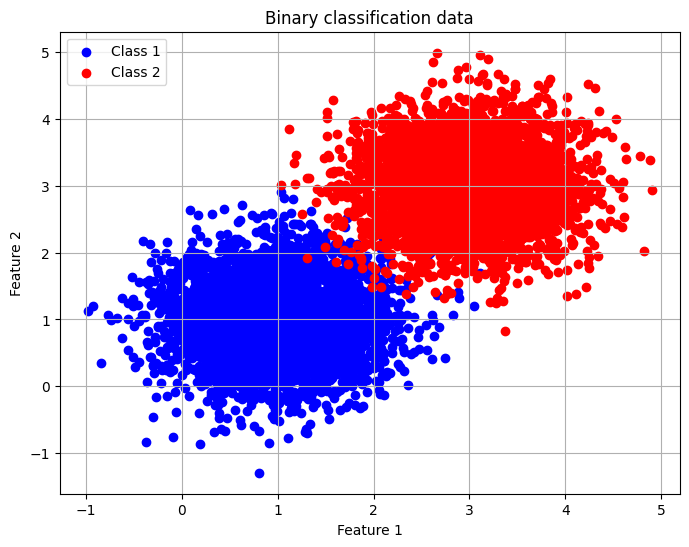

In [11]:
##################################################
#Generating binary classification data (linearly separable)
##################################################
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

mean1 = [1,1]
mean2 = [3,3]
cov = [[0.3,0],[0,0.3]]
class1_tr = np.random.multivariate_normal(mean1, cov, size=(4500))
class2_tr = np.random.multivariate_normal(mean2, cov, size=(4500))

tr_data = np.concatenate([class1_tr, class2_tr], axis=0)
tr_targets = np.concatenate([np.zeros(len(class1_tr)), np.ones(len(class2_tr))])

class1_te = np.random.multivariate_normal(mean1, cov, size=(500))
class2_te = np.random.multivariate_normal(mean2, cov, size=(500))

te_data = np.concatenate([class1_te, class2_te], axis=0)
te_targets = np.concatenate([np.zeros(len(class1_te)), np.ones(len(class2_te))])

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(class1_tr[:, 0], class1_tr[:, 1], color='blue', label='Class 1')
plt.scatter(class2_tr[:, 0], class2_tr[:, 1], color='red', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary classification data')
plt.legend()
plt.grid(True)
plt.show()


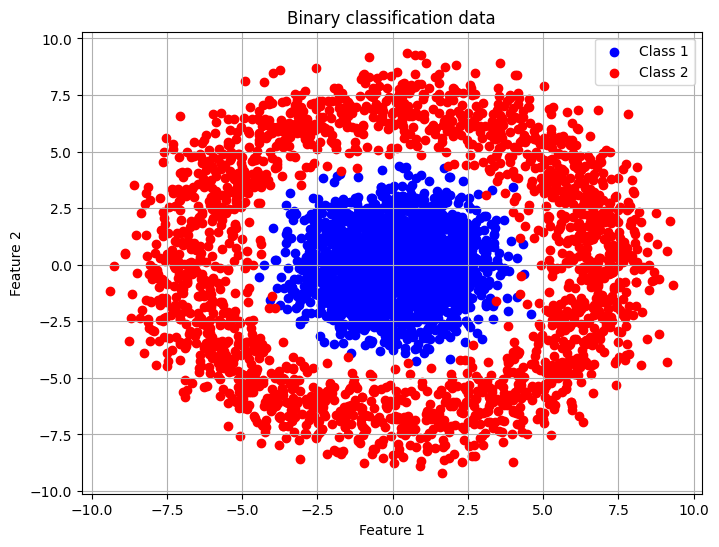

In [12]:
##################################################
#Generating binary classification data (non-linearly separable)
##################################################
import numpy as np
import matplotlib.pyplot as plt

# Function to generate data for concentric circles
def generate_concentric_data(n_samples, radius1,radius2, noise_std):
    # Generate random angles
    angles = np.random.rand(n_samples) * 2 * np.pi
    noise = noise_std*np.random.randn(n_samples)
    # Generate inner and outer circles
    inner_circle = np.array([(radius1 + noise) * np.cos(angles), (radius1 + noise) * np.sin(angles)]).T
    outer_circle = np.array([(radius2 + noise) * np.cos(angles), (radius2 + noise) * np.sin(angles)]).T
    return inner_circle, outer_circle

# Generate data for two classes
n_samples = 2000  # Number of samples for each class
radius1 = 2  # Radius of inner circle
radius2 = 7  # Radius of inner circle
noise_std = 1   # Noise to be added to radius

class1_data, class2_data = generate_concentric_data(n_samples, radius1,radius2,noise_std)

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(class1_data[:, 0], class1_data[:, 1], color='blue', label='Class 1')
plt.scatter(class2_data[:, 0], class2_data[:, 1], color='red', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary classification data')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
##################################################
#Classify the linearly separable data using linear classification models
##################################################
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def Logistic_Regression(X_train, y_train, X_test):

    max_iter = 100
    X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))  #augmented
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
    w = np.random.randn(X_train.shape[1])

    for _ in range(max_iter):
        y_pred = sigmoid(X_train @ w)
        R = y_pred * (1 - y_pred)
        H = X_train.T @ (R[:, None] * X_train)
        gradient = X_train.T @ (y_pred - y_train)
        w = w - np.linalg.pinv(H) @ gradient

    # Predict on test data
    test_preds = sigmoid(X_test @ w)
    test_preds = (test_preds >= 0.5).astype(int)

    return test_preds, w

def accuracy(predictions, labels):
    return np.mean(predictions == labels) * 100

def plot_decision_boundary(X, y, w):
    plt.figure(figsize=(12, 8))
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], label='Class 1', alpha=0.6)
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='Class 2', alpha=0.6)

    x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    y_vals = -(w[0] + w[1]*x_vals) / w[2]
    plt.plot(x_vals, y_vals, label='Decision Boundary')

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Logistic Regression Decision Boundary")
    plt.legend()
    plt.show()

# Train and test logistic regression
log_preds, log_w = Logistic_Regression(tr_data, tr_targets, te_data)
log_acc = accuracy(log_preds, te_targets)
print(f"Logistic Regression Test Accuracy: {log_acc:.2f}%")
plot_decision_boundary(tr_data, tr_targets, log_w)

##################################################
#Classify the linearly separable data using deep neural based classification models
##################################################
def relu(x):
    return np.maximum(0, x)

def grad_relu(x):
    return np.where(x > 0, 1, 0)

# Forward propagation (with bias terms: without biases a ReLU network is positively
# homogeneous, its decision boundary is a cone of rays through the origin, and problems
# where the class depends on the radius (e.g., concentric circles) cannot be learned)
def forward_propagation(x, weights):
    W1, b1, W2, b2, W3, b3 = weights
    z1 = x @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = relu(z2)
    z3 = a2 @ W3 + b3
    y_hat = sigmoid(z3)

    return [y_hat, z1, a1, z2, a2, z3]

# Backward propagation
def backward_propagation(x, y, weights, activations, learning_rate):
    W1, b1, W2, b2, W3, b3 = weights
    y_hat, z1, a1, z2, a2, z3 = activations

    dj_dz3 = (y_hat - y)
    dj_dw3 = a2.T @ dj_dz3 / (x.shape[0] + (1e-10))
    dj_db3 = np.mean(dj_dz3, axis=0)
    dj_da2 = dj_dz3 @ W3.T
    dj_dz2 = dj_da2 * grad_relu(z2)
    dj_dw2 = a1.T @ dj_dz2 / (x.shape[0] + (1e-10))
    dj_db2 = np.mean(dj_dz2, axis=0)
    dj_da1 = dj_dz2 @ W2.T
    dj_dz1 = dj_da1 * grad_relu(z1)
    dj_dw1 = x.T @ dj_dz1 / (x.shape[0] + (1e-10))
    dj_db1 = np.mean(dj_dz1, axis=0)

    W1 = W1 - learning_rate * dj_dw1
    b1 = b1 - learning_rate * dj_db1
    W2 = W2 - learning_rate * dj_dw2
    b2 = b2 - learning_rate * dj_db2
    W3 = W3 - learning_rate * dj_dw3
    b3 = b3 - learning_rate * dj_db3

    weights = [W1, b1, W2, b2, W3, b3]

    return [dj_dw1, dj_dw2, dj_dw3], weights

def training(x, y, epochs=200, learning_rate=0.1, batch_size=128):

  hidden_units = 3
  n_classes = 1

  #Randomly initialize the weights (He initialization for the hidden layers and small
  #random values for the output layer so the sigmoid outputs can move in both directions)
  W1 = np.random.randn(x.shape[1], hidden_units) * np.sqrt(2.0 / x.shape[1])
  b1 = np.zeros(hidden_units)
  W2 = np.random.randn(hidden_units, hidden_units) * np.sqrt(2.0 / hidden_units)
  b2 = np.zeros(hidden_units)
  W3 = np.random.randn(hidden_units, n_classes) * 0.1
  b3 = np.zeros(n_classes)
  weights = [W1, b1, W2, b2, W3, b3]

  y = y.reshape(-1, 1)
  n_samples = len(x)

  #Mini-batch training with shuffling so that the network converges properly
  for epoch in range(epochs):
        indices = np.random.permutation(n_samples)
        x_shuffled, y_shuffled = x[indices], y[indices]
        for b in range(n_samples // batch_size):
            xb = x_shuffled[b * batch_size:(b + 1) * batch_size]
            yb = y_shuffled[b * batch_size:(b + 1) * batch_size]
            activations = forward_propagation(xb, weights)
            gradients, weights = backward_propagation(xb, yb, weights, activations, learning_rate)

  trained_weights = weights

  return trained_weights

def test_perf(inputs, targets, weights):
  #Forward propagation
  activations = forward_propagation(inputs, weights)
  outputs = activations[0]

  #Compute accuracy, and error
  predictions = np.round(outputs).flatten()
  accuracy_val = np.mean(predictions == targets)
  error = 1 - accuracy_val
  return accuracy_val, error

def dnn_decision_boundary(X, y, trained_weights, title='Decision Boundary (DNN)'):

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    preds = forward_propagation(grid, trained_weights)[0]
    Z = preds.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.6, levels=np.linspace(0, 1, 3), cmap='coolwarm')
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 1', alpha=0.6)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 2', alpha=0.6)
    plt.title(title)
    plt.legend()
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

def plot_activation_potentials(X, y, trained_weights):

    activations = forward_propagation(X, trained_weights)
    second_layer_activations = activations[3]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(second_layer_activations[y == 0, 0], second_layer_activations[y == 0, 1], second_layer_activations[y == 0, 2], c='blue', label='Class 1', alpha=0.6)
    ax.scatter(second_layer_activations[y == 1, 0], second_layer_activations[y == 1, 1], second_layer_activations[y == 1, 2], c='red', label='Class 2', alpha=0.6)
    ax.set_title('Second Layer Activation Potentials (3D)')
    ax.set_xlabel('Activation 1')
    ax.set_ylabel('Activation 2')
    ax.set_zlabel('Activation 3')
    ax.legend()
    plt.show()

tr_data = (tr_data - tr_data.mean(axis=0)) / tr_data.std(axis=0)
te_data = (te_data - te_data.mean(axis=0)) / te_data.std(axis=0)

trained_weights = training(tr_data, tr_targets, epochs = 200, learning_rate = 0.1)

dnn_decision_boundary(tr_data, tr_targets, trained_weights)
plot_activation_potentials(tr_data, tr_targets, trained_weights)

dnn_test_accuracy, test_error = test_perf(te_data, te_targets, trained_weights)
print(f"Test Accuracy for DNN: {dnn_test_accuracy * 100:.2f}%")
##################################################
#Compare the performance of both the models on linearly separable data
##################################################

print("\nComparison:")
if dnn_test_accuracy * 100 > log_acc:
    print("DNN performs better on linearly separable data.")
else:
    print("Logistic Regression performs better on linearly separable data.")

In [ ]:
data = np.vstack((class1_data, class2_data))
labels = np.hstack((np.zeros(len(class1_data)), np.ones(len(class2_data))))

indices = np.arange(data.shape[0])
np.random.shuffle(indices)
split_idx = int(0.9 * data.shape[0])
train_idx, test_idx = indices[:split_idx], indices[split_idx:]
tr_data, te_data = data[train_idx], data[test_idx]
tr_targets, te_targets = labels[train_idx], labels[test_idx]

##################################################
#Classify the non-linearly separable data using linear classification models
##################################################
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def Logistic_Regression(X_train, y_train, X_test):
    max_iter = 100
    X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))  # augmented
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
    w = np.random.randn(X_train.shape[1])
    for _ in range(max_iter):
        y_pred = sigmoid(X_train @ w)
        R = y_pred * (1 - y_pred)
        H = X_train.T @ (R[:, None] * X_train)
        gradient = X_train.T @ (y_pred - y_train)
        w = w - np.linalg.pinv(H) @ gradient
    test_preds = sigmoid(X_test @ w)
    test_preds = (test_preds >= 0.5).astype(int)
    return test_preds, w

def accuracy(predictions, labels):
    return np.mean(predictions == labels) * 100

def plot_decision_boundary(X, y, w):
    plt.figure(figsize=(10, 6))
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], label='Class 1', alpha=0.5)
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='Class 2', alpha=0.5)
    x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_vals = -(w[0] + w[1] * x_vals) / w[2]
    plt.plot(x_vals, y_vals, label='Decision Boundary', color='black')
    plt.title('Logistic Regression (Linear Model)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

log_preds, log_w = Logistic_Regression(tr_data, tr_targets, te_data)
log_acc = accuracy(log_preds, te_targets)
print(f"Logistic Regression Test Accuracy: {log_acc:.2f}%")
plot_decision_boundary(tr_data, tr_targets, log_w)

##################################################
#Classify the non-linearly separable data using deep neural based classification models
##################################################
def relu(x): return np.maximum(0, x)
def grad_relu(x): return np.where(x > 0, 1, 0)

# Forward propagation (with bias terms: without biases a ReLU network is positively
# homogeneous and its decision boundary is a cone through the origin, so the class of a
# point could only depend on the direction of x and concentric circles could not be learned)
def forward_propagation(x, weights):
    W1, b1, W2, b2, W3, b3 = weights
    z1 = x @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = relu(z2)
    z3 = a2 @ W3 + b3
    y_hat = sigmoid(z3)
    return [y_hat, z1, a1, z2, a2, z3]

def backward_propagation(x, y, weights, activations, lr):
    W1, b1, W2, b2, W3, b3 = weights
    y_hat, z1, a1, z2, a2, z3 = activations
    dj_dz3 = y_hat - y
    dj_dw3 = a2.T @ dj_dz3 / len(x)
    dj_db3 = np.mean(dj_dz3, axis=0)
    dj_dz2 = (dj_dz3 @ W3.T) * grad_relu(z2)
    dj_dw2 = a1.T @ dj_dz2 / len(x)
    dj_db2 = np.mean(dj_dz2, axis=0)
    dj_dz1 = (dj_dz2 @ W2.T) * grad_relu(z1)
    dj_dw1 = x.T @ dj_dz1 / len(x)
    dj_db1 = np.mean(dj_dz1, axis=0)
    W1 -= lr * dj_dw1
    b1 -= lr * dj_db1
    W2 -= lr * dj_dw2
    b2 -= lr * dj_db2
    W3 -= lr * dj_dw3
    b3 -= lr * dj_db3
    return [dj_dw1, dj_dw2, dj_dw3], [W1, b1, W2, b2, W3, b3]

def training(x, y, epochs=200, learning_rate=0.1, batch_size=128):
    hidden_units = 3
    W1 = np.random.randn(x.shape[1], hidden_units) * np.sqrt(2.0 / x.shape[1])
    b1 = np.zeros(hidden_units)
    W2 = np.random.randn(hidden_units, hidden_units) * np.sqrt(2.0 / hidden_units)
    b2 = np.zeros(hidden_units)
    W3 = np.random.randn(hidden_units, 1) * 0.1
    b3 = np.zeros(1)
    weights = [W1, b1, W2, b2, W3, b3]
    y = y.reshape(-1, 1)
    n_samples = len(x)
    for _ in range(epochs):
        indices = np.random.permutation(n_samples)
        x_shuffled, y_shuffled = x[indices], y[indices]
        for b in range(n_samples // batch_size):
            xb = x_shuffled[b * batch_size:(b + 1) * batch_size]
            yb = y_shuffled[b * batch_size:(b + 1) * batch_size]
            activations = forward_propagation(xb, weights)
            _, weights = backward_propagation(xb, yb, weights, activations, learning_rate)
    return weights

def test_perf(inputs, targets, weights):
    outputs = forward_propagation(inputs, weights)[0]
    preds = np.round(outputs)
    acc = np.mean(preds.flatten() == targets)
    return acc, 1 - acc

def dnn_decision_boundary(X, y, weights, title='DNN Decision Boundary'):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = forward_propagation(grid, weights)[0]
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.6, cmap='coolwarm', levels=np.linspace(0, 1, 3))
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], label='Class 1', alpha=0.5)
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='Class 2', alpha=0.5)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

def plot_activation_potentials(X, y, weights):
    _, _, _, _, a2, _ = forward_propagation(X, weights)
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(a2[y==0, 0], a2[y==0, 1], a2[y==0, 2], label='Class 1', c='blue', alpha=0.6)
    ax.scatter(a2[y==1, 0], a2[y==1, 1], a2[y==1, 2], label='Class 2', c='red', alpha=0.6)
    ax.set_title('Second Layer Activations')
    ax.set_xlabel('A1')
    ax.set_ylabel('A2')
    ax.set_zlabel('A3')
    ax.legend()
    plt.show()

# Train and evaluate DNN
trained_weights = training(tr_data, tr_targets, epochs = 200, learning_rate = 0.1)
dnn_decision_boundary(tr_data, tr_targets, trained_weights)
plot_activation_potentials(tr_data, tr_targets, trained_weights)

dnn_test_accuracy, test_error = test_perf(te_data, te_targets, trained_weights)
print(f"DNN Test Accuracy: {dnn_test_accuracy * 100:.2f}%")

##################################################
#Compare the performance of both the models on non-linearly separable data
##################################################

print("\nComparison:")
if dnn_test_accuracy * 100 > log_acc:
    print("DNN performed better than Logistic Regression on non-linearly separable data.")
elif dnn_test_accuracy * 100 < log_acc:
    print("Logistic Regression performed better than DNN on non-linearly separable data.")
else:
    print("Both models performed equally well on non-linearly separable data.")

<b> Report your observations </b>

1. For linearly separable data both models perform excellently: logistic regression achieves a test accuracy of 99.40% and the DNN 99.30% - for linearly separable data a simple linear classifier is already sufficient.

2. For non-linearly separable data (concentric circles) logistic regression drops to 69.25% because a linear decision boundary cannot capture the ring structure, while the DNN achieves 100% by learning the non-linear boundary.

3. The DNN clearly outperforms the linear classifier on non-linear data. Note that for the network to converge it needs bias terms (without biases a ReLU network is positively homogeneous and its decision boundary is a cone of rays through the origin, so a class that depends on the radius of x cannot be learned), a proper weight initialization and mini-batch training with shuffling.